In [1]:
import numpy as np

from pysrc.analysis import compute_planner_value
from pysrc.optimization import PlannerSolution, solve_planner_problem
from pysrc.services.data_service import load_productivity_params, load_site_data

## Model scenario

In [2]:
opt = "gurobi"
pee = 6.6
pa = 41.11
b = 25
sitenum = 1043
T = 200
h = 51

## Solve model

In [3]:
(zbar_2017, z_2017, forest_area_2017) = load_site_data(sitenum)

# Load baseline productivity params
(theta, gamma) = load_productivity_params(sitenum)

# Computing carbon absorbed in start period
x0_vals = gamma * forest_area_2017

results = solve_planner_problem(
    time_horizon=T + h,
    theta=theta,
    gamma=gamma,
    x0=x0_vals,
    zbar=zbar_2017,
    z0=z_2017,
    price_emissions=pee + b,
    price_cattle=pa,
)

Solving the optimization problem...
Set parameter Username

--------------------------------------------
--------------------------------------------

Academic license - for non-commercial use only - expires 2025-11-04
Read LP format model from file /var/folders/d1/k6sr3htd7fdgk614mmq8pwq00000gr/T/tmp83507inz.pyomo.lp
Reading time = 1.32 seconds
x1: 524841 rows, 1047927 columns, 2616558 nonzeros
Set parameter NonConvex to value 2
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (mac64[arm])

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 524841 rows, 1047927 columns and 2616558 nonzeros
Model fingerprint: 0xc532178f
Model has 753 quadratic objective terms
Variable types: 1047926 continuous, 1 integer (1 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+08]
  Objective range  [3e-04, 6e+03]
  QObjective range [1e-02, 2e+05]
  Bounds range     [3e-06, 1e+00]
  RHS range        [9e-11, 1e+08]
Presolve remo

## Compute the continuation value (in time $t$ dollars)

In [4]:
V = [
    compute_planner_value(
        pee=pee,
        pa=pa,
        b=b,
        r=0,
        theta=theta,
        zbar=zbar_2017,
        solution=PlannerSolution(
            results.Z[t:],
            results.X[t:],
            results.U[t:],
            results.V[t:],
        ),
        T=T,
    )["planner_value"]
    for t in range(h)
]

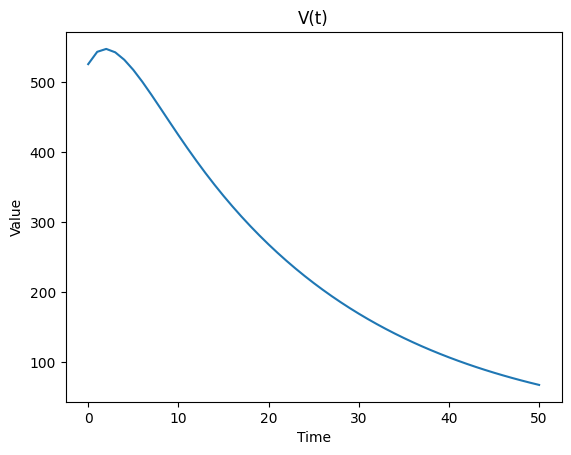

In [5]:
import matplotlib.pyplot as plt

# Plotting the line plot
plt.plot(V)

# Adding labels and title
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("V(t)")

# Displaying the plot
plt.show()

## Compute the defecting value (in time $t$ dollars)

In [6]:
W = []
for t in range(h):
    # Solve for the optimal defecting trajectory (b=0)
    defection = solve_planner_problem(
        time_horizon=T,
        theta=theta,
        gamma=gamma,
        x0=results.X[t],
        zbar=zbar_2017,
        z0=results.Z[t],
        price_emissions=pee,
        price_cattle=pa,
    )

    # Compute time t value of this trajectory
    W.append(
        compute_planner_value(
            pee=pee,
            pa=pa,
            b=0,
            r=0,
            theta=theta,
            zbar=zbar_2017,
            solution=defection,
            T=T,
        )["planner_value"]
    )

Solving the optimization problem...
Set parameter Username

--------------------------------------------
--------------------------------------------

Academic license - for non-commercial use only - expires 2025-11-04
Read LP format model from file /var/folders/d1/k6sr3htd7fdgk614mmq8pwq00000gr/T/tmp465opot1.pyomo.lp
Reading time = 1.27 seconds
x1: 418200 rows, 835002 columns, 2084271 nonzeros
Set parameter NonConvex to value 2
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (mac64[arm])

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 418200 rows, 835002 columns and 2084271 nonzeros
Model fingerprint: 0x381e6f2f
Model has 600 quadratic objective terms
Variable types: 835001 continuous, 1 integer (1 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+08]
  Objective range  [1e-03, 1e+03]
  QObjective range [4e-02, 2e+05]
  Bounds range     [3e-06, 1e+00]
  RHS range        [9e-11, 1e+08]
Presolve removed

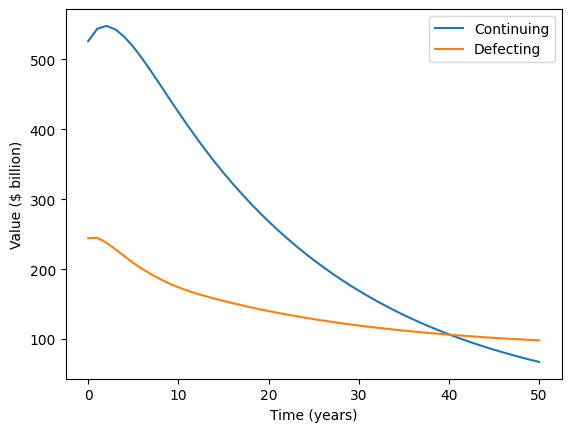

In [7]:
# Plotting the line plots for V and W
plt.plot(V, label="Continuing")
plt.plot(W, label="Defecting")

# Adding legend
plt.legend()

# Adding labels and title
plt.xlabel("Time (years)")
plt.ylabel("Value ($ billion)")
# plt.title("Value under b=$25 scheme v.s defecting")

# Displaying the plot
plt.show()

## Time of defecting

In [8]:
def defect_time(V, W):
    indices = [i for i, (v, w) in enumerate(zip(V, W)) if v < w]
    return indices[0] if indices else -1

In [9]:
defect_time(V, W)

41

## Present-valued difference between $V(t)$ and $W(t)$

In [10]:
# Compute PV "gap" between continuation and defecting values
PV_diff = [(V[t] - W[t]) / (1.02**t) for t in range(h)]

In [11]:
PV_diff[49]

-10.707876638738124

## Stick policy
- Withhold fraction $p$ of transfers
- Place these payments in a fund which earns interest (same as discount rate)
- Value of defecting is old value - value of the fund

In [12]:
# Set parameters for computing fund payments
kappa = 2.094215255
delta = 0.02
p = 0.04

# Compute change in X
X_dot = np.diff(results.X, axis=0)

# Compute fund payments
fund_payments = [
    -b * p * (kappa * np.sum(results.Z[t + 1]) - np.sum(X_dot[t])) for t in range(T)
]

# Compute fund value
fund_value = [fund_payments[0]]
for t in range(h - 1):
    fund_value.append(fund_payments[t + 1] + (1 + delta) * fund_value[t])

# Compute value of defecting under "stick" policy
new_W = [W[t] - fund_value[t] for t in range(h)]

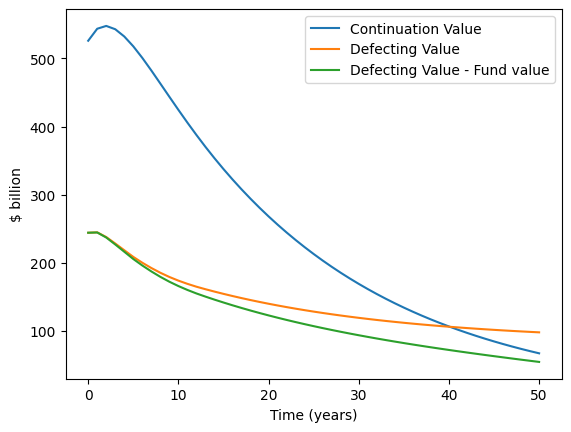

In [13]:
# Plotting the line plots for V and W
plt.plot(V, label="Continuation Value")
plt.plot(W, label="Defecting Value")
plt.plot(new_W, label="Defecting Value - Fund value")

# Adding legend
plt.legend()

# Adding labels and title
plt.xlabel("Time (years)")
plt.ylabel("$ billion")

# Displaying the plot
plt.show()